# Project Introduction

## Neural Networks and Deep Learning for Medical Cost Prediction

In this project, we build and train a **neural network using Keras** to predict **individual medical insurance costs** based on personal and demographic characteristics. The goal is to apply core deep learning concepts end to end, from data exploration and preprocessing to model design, training, evaluation, and interpretation.

Healthcare costs vary widely across individuals due to factors such as age, lifestyle, and health indicators. By modeling these relationships with a neural network, this project demonstrates how deep learning can be applied to **regression problems** involving real-world, structured tabular data.

The project uses a publicly available **medical insurance dataset** containing demographic information and billed insurance charges. The target variable, `charges`, represents the total medical costs incurred by each individual.

---

## Project Objectives

The primary objectives of this project are to:

- Explore and understand a real-world healthcare dataset  
- Prepare mixed numerical and categorical data for neural network training  
- Design and train a regression-focused neural network using Keras  
- Evaluate model performance using appropriate metrics  
- Visualize training behavior and prediction accuracy  
- Analyze results and reflect on model strengths and limitations  

By completing this project, we reinforce best practices in deep learning workflows, including **data normalization**, **train-test splitting**, **overfitting diagnostics**, and **iterative model improvement**.

---

## Dataset Overview

- **Source:**  
  https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv  

- **Description:**  
  The dataset contains information about health insurance beneficiaries and the medical costs billed by their insurance provider.

- **Target Variable:**  
  - `charges`: Individual medical insurance costs

- **Key Features:**  
  - `age`: Age of the primary beneficiary  
  - `sex`: Gender  
  - `bmi`: Body mass index (kg/m²)  
  - `children`: Number of dependents covered  
  - `smoker`: Smoking status  
  - `region`: Residential region in the US  

---

## Why Neural Networks?

While traditional regression models can perform well on this dataset, neural networks provide:

- The ability to model **nonlinear relationships**  
- Flexibility in architecture design  
- Practical experience with **deep learning frameworks** used in industry  

This project emphasizes understanding *why* modeling decisions are made, not just achieving low error metrics.

---

## Outcome

By the end of this project, we produce a trained neural network capable of predicting medical insurance charges, supported by clear evaluation metrics, visual diagnostics, and a thoughtful analysis of results and potential improvements.

## Environment Setup and Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from sklearn.model_selection import train_test_split
import json
import os
import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from tensorflow.keras.optimizers import Adam

import time

## Step 1: Loading and Initial Data Exploration

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [6]:
df.duplicated().sum()

1

In [7]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


### Findings

No obvious signs of structural errors to fix. Columns and Dtypes are aligned and no nulls. 

## Data preparation & EDA

In [9]:
#Run value_counts to check for outliers or value errors
#sake of space... Only showing last value_count due no outliers or errors
df[df['charges']>=50000].value_counts()

age  sex     bmi     children  smoker  region     charges    
28   male    36.400  1         yes     southwest  51194.55914    1
31   female  38.095  1         yes     northeast  58571.07448    1
33   female  35.530  0         yes     northwest  55135.40209    1
45   male    30.360  0         yes     southeast  62592.87309    1
52   male    34.485  3         yes     northwest  60021.39897    1
54   female  47.410  0         yes     southeast  63770.42801    1
60   male    32.800  0         yes     southwest  52590.82939    1
dtype: int64

In [10]:
def plot_feature_distributions(df, name):
    """
    Plot distributions for numeric and categorical features in a DataFrame.
    Numeric features: histogram + KDE
    Categorical features: count plot
    """
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

    all_cols = list(num_cols) + list(cat_cols)

    n_cols = 2
    n_rows = int(np.ceil(len(all_cols) / n_cols))

    plt.figure(figsize=(14, n_rows * 4))
    plt.suptitle(f"Distributions for {name}", fontsize=16, y=1.02)

    for i, col in enumerate(all_cols):
        plt.subplot(n_rows, n_cols, i + 1)

        if col in num_cols:
            sns.histplot(df[col], kde=True, bins=30)
            plt.ylabel("Frequency")
        else:
            sns.countplot(
                x=df[col],
                order=df[col].value_counts().index
            )
            plt.ylabel("Count")
            plt.xticks(rotation=30)

        plt.title(col)
        plt.xlabel("")

    plt.tight_layout()
    plt.show()

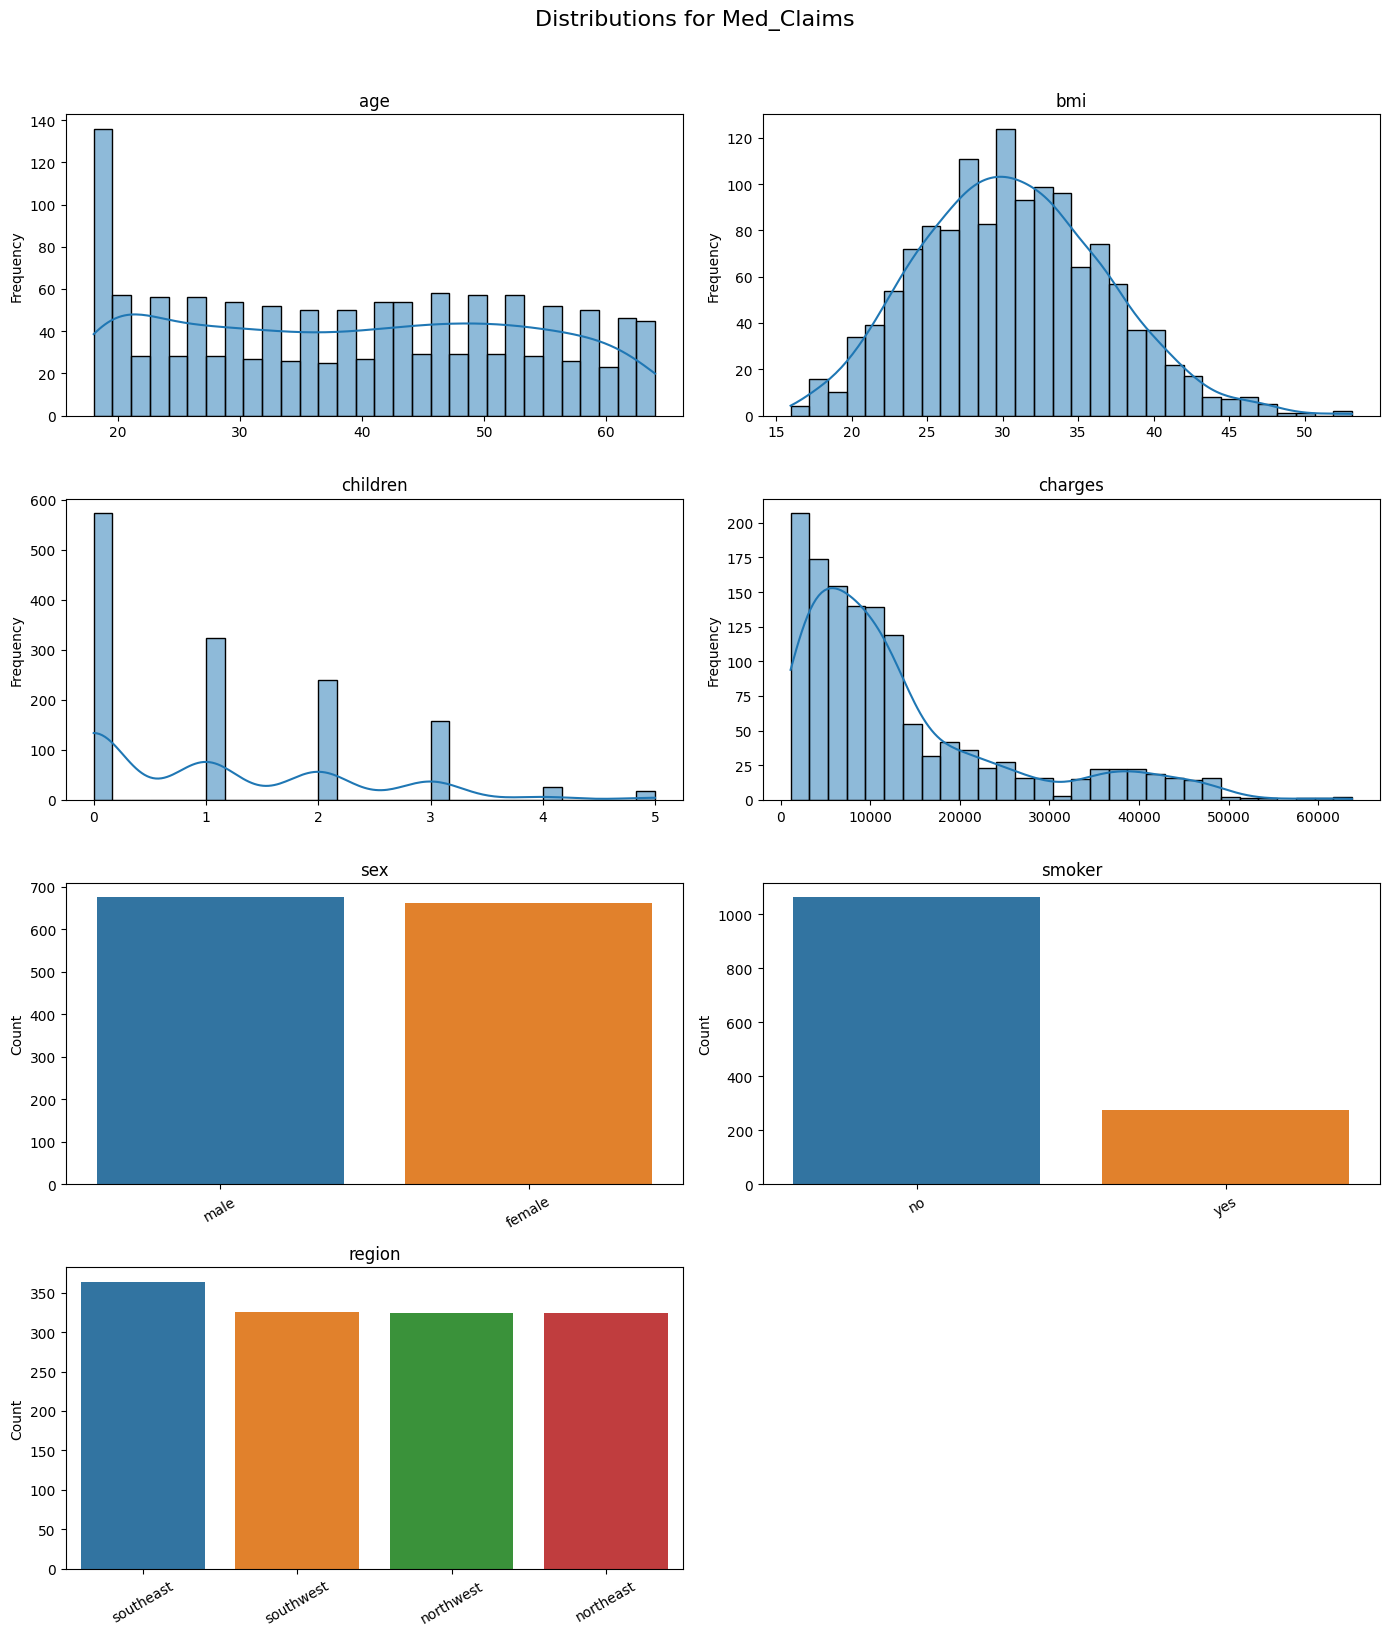

In [11]:
plot_feature_distributions(df, 'Med_Claims')

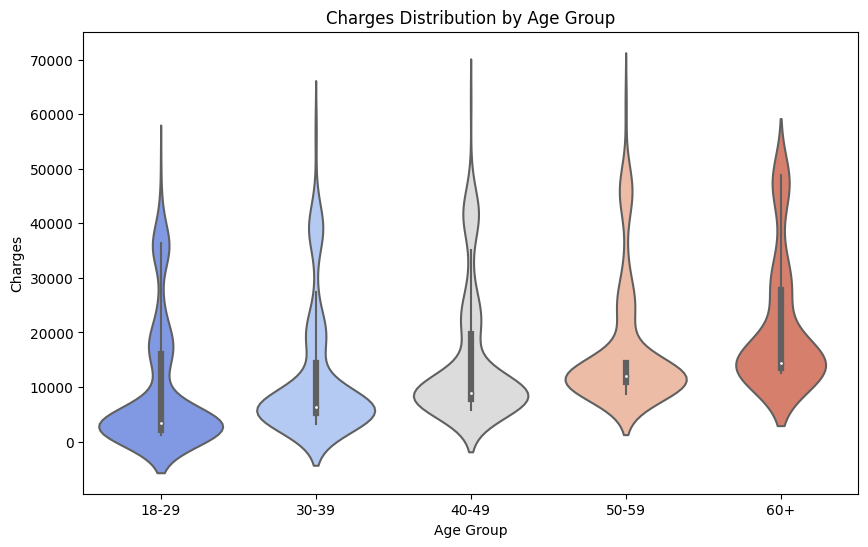

In [12]:


df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 30, 40, 50, 60, 70 ],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"]
)



plt.figure(figsize=(10, 6))

sns.violinplot(
    x="age_group",
    y="charges",
    data=df,
    palette="coolwarm"
)

plt.title("Charges Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Charges")

plt.show()

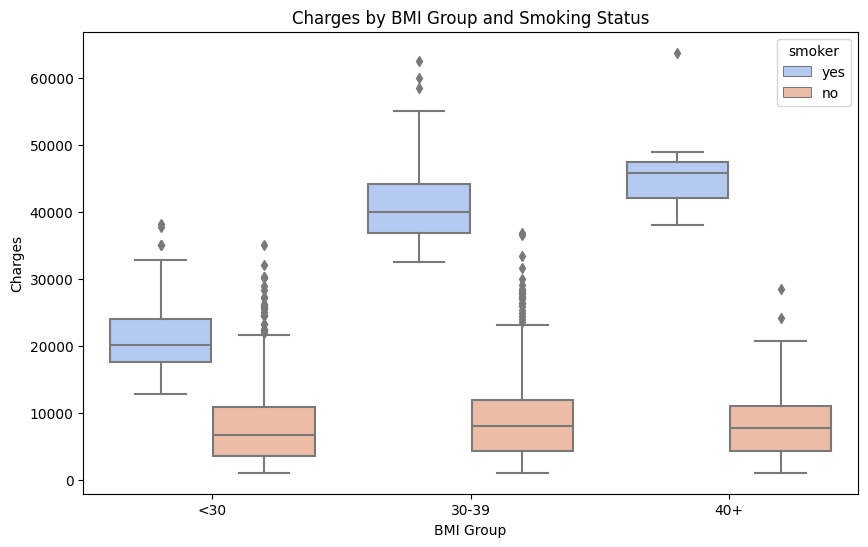

In [13]:
df["bmi_group"] = pd.cut(
    df["bmi"],
    bins=[15, 30, 40, 60],  # upper bound increased to capture max BMI
    labels=["<30", "30-39", "40+"],
    include_lowest=True
)
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="bmi_group",
    y="charges",
    hue="smoker",
    data=df,
    palette="coolwarm"
)

plt.title("Charges by BMI Group and Smoking Status")
plt.xlabel("BMI Group")
plt.ylabel("Charges")

plt.show()



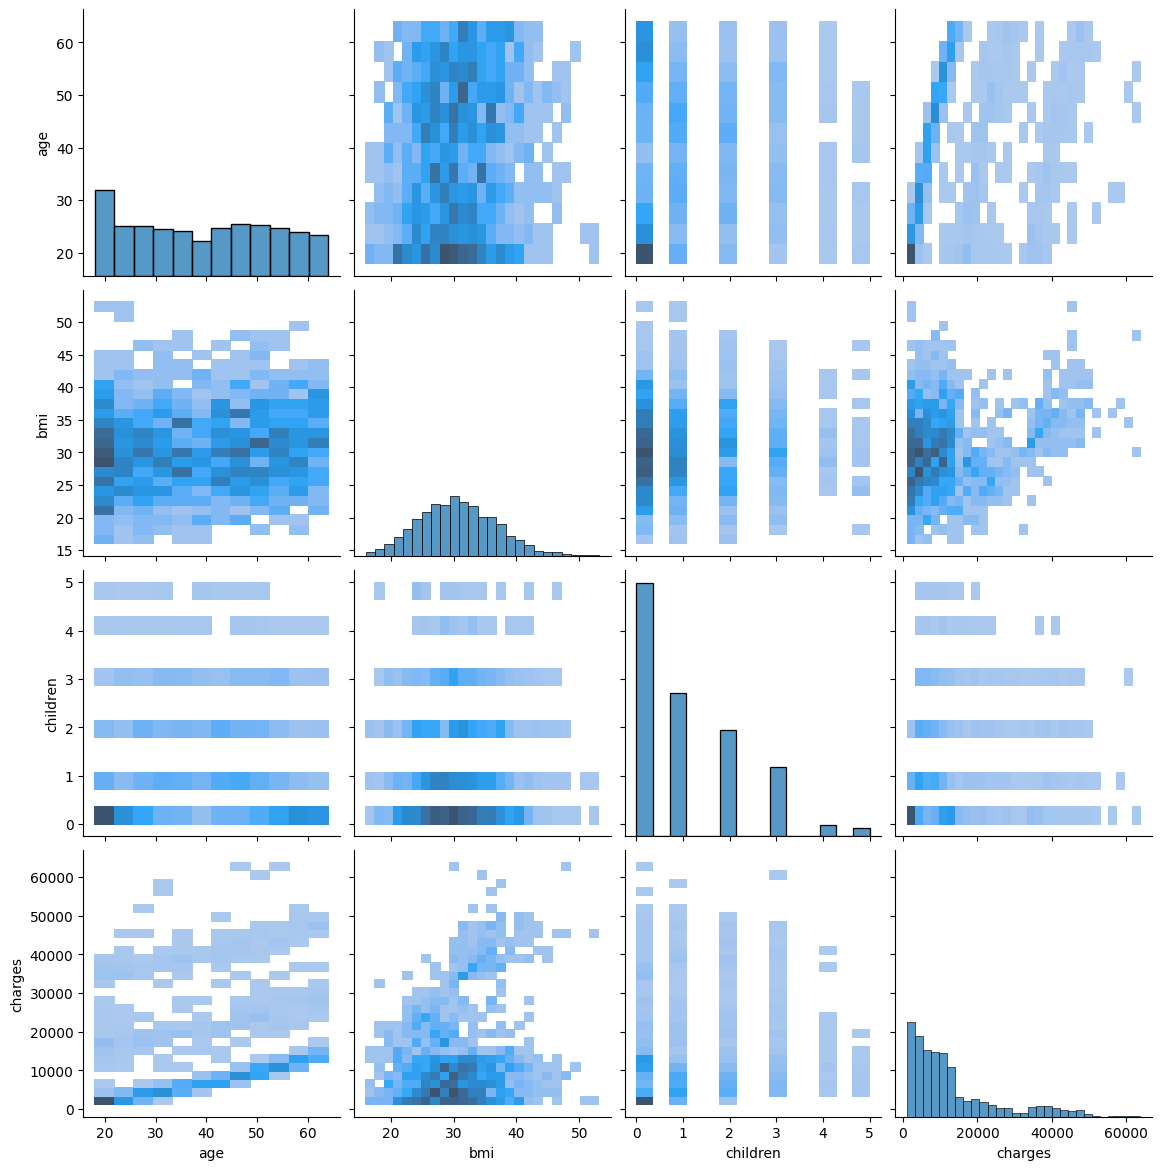

In [14]:
df = df.drop(['age_group', 'bmi_group'], axis = 1)
g = sns.pairplot(df.select_dtypes(include=["int64", "float64"]),kind='hist')
g.fig.set_size_inches(12, 12)
plt.show()

# Exploratory Data Analysis – Insurance Dataset

## 1. Feature Distributions

The first visualization displays the univariate distributions of all features in the dataset, including both numerical and categorical variables.

### Numerical Features

**Age**
- The age distribution is relatively uniform between approximately 18 and 64.
- There is no strong skewness.
- The dataset appears well-balanced across adult age groups.

**BMI**
- BMI follows an approximately normal distribution centered around 30.
- Slight right skew is visible, with a few higher-BMI outliers above 45.
- This suggests most individuals fall within overweight to moderately obese categories.

**Children**
- This is a discrete variable ranging from 0 to 5.
- The majority of individuals have 0–2 children.
- Higher numbers of dependents are progressively less common.

**Charges (Target Variable)**
- The distribution is heavily right-skewed.
- Most individuals incur relatively low medical costs.
- A smaller group has very high charges (long right tail reaching above 60,000).
- This skewness suggests:
  - Potential benefit from log transformation
  - Presence of high-cost subgroups (likely smokers or high-risk individuals)

---

### Categorical Features

**Sex**
- Nearly evenly split between male and female.
- No obvious imbalance.

**Smoker**
- Strong class imbalance.
- Non-smokers significantly outnumber smokers.
- This variable is likely to have strong predictive power due to known medical cost differences.

**Region**
- Fairly balanced distribution across all four regions.
- No severe geographic imbalance is present.

---

## 2. Pairwise Relationships Between Numerical Features

The second visualization shows pairwise relationships and joint distributions between numerical variables (age, BMI, children, charges).

### Age vs Charges
- Clear upward trend.
- Medical costs generally increase with age.
- However, high-cost outliers appear across multiple age groups, suggesting interaction effects.

### BMI vs Charges
- Positive association is visible.
- Higher BMI values tend to correspond with higher medical charges.
- Relationship appears nonlinear and dispersed.

### Children vs Charges
- No strong linear relationship.
- Costs do not increase dramatically with number of dependents.
- This feature may have weaker predictive influence.

### Charges Distribution (Diagonal)
- Reconfirms strong right skew.
- Majority of costs cluster below 15,000.
- Long tail of high-cost individuals drives variance.

---

## 3. Key Insights from Combined Analysis

1. Insurance charges are not normally distributed and are strongly right-skewed.
2. Age and BMI show visible positive relationships with medical costs.
3. Smoking status (from prior analysis) is likely a major driver of high-cost clusters.
4. Children appears to contribute less strongly to cost variation.
5. The dataset contains nonlinear patterns, supporting the use of flexible models such as neural networks.

---

## 4. Modeling Implications

- Target transformation (log scaling) may stabilize neural network training.
- Smoking status and BMI are likely high-importance features.
- Interactions between age, BMI, and smoking may explain high-cost outliers.
- Linear models may struggle to capture nonlinear clustering patterns.

---

## Conclusion

The exploratory analysis reveals structured variation in both feature distributions and pairwise relationships. Medical insurance charges are strongly skewed and influenced by demographic and lifestyle factors, particularly age, BMI, and smoking status.

These findings support proceeding with nonlinear modeling techniques such as neural networks while carefully handling skewness in the target variable.

## EDA- PCA

In [15]:
X = df.drop(columns="charges")
y = df["charges"]
X_encoded = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)


In [16]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

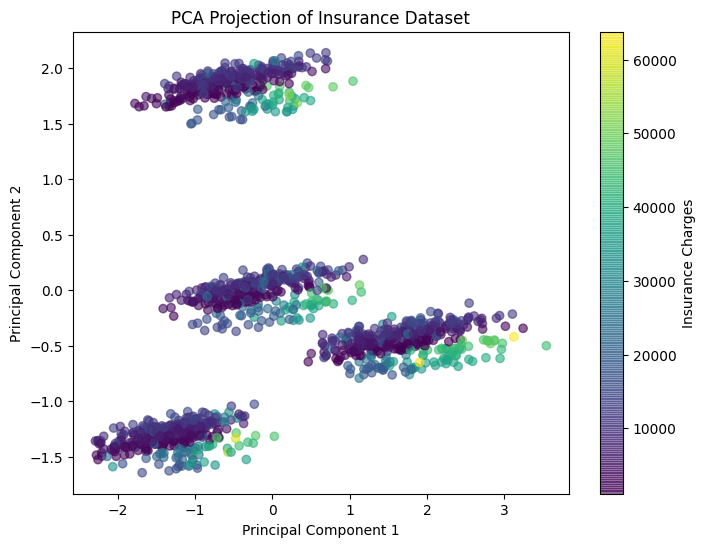

In [17]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Insurance Charges")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Insurance Dataset")
plt.show()


In [18]:
pca.explained_variance_ratio_

array([0.19216322, 0.16583517, 0.13704414, 0.132862  ])

In [19]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3","PC4"],
    index=X_encoded.columns
)

loadings.sort_values("PC1", ascending=False).head()

,PC1,PC2,PC3,PC4
region_southeast,0.685927,-0.213999,0.035837,-0.149320
bmi,0.488404,0.060877,-0.313235,0.131901
smoker_yes,0.144512,-0.077895,0.483192,0.415770
sex_male,0.093752,-0.010708,0.345384,0.601830
age,0.065966,0.059230,-0.673048,0.285601


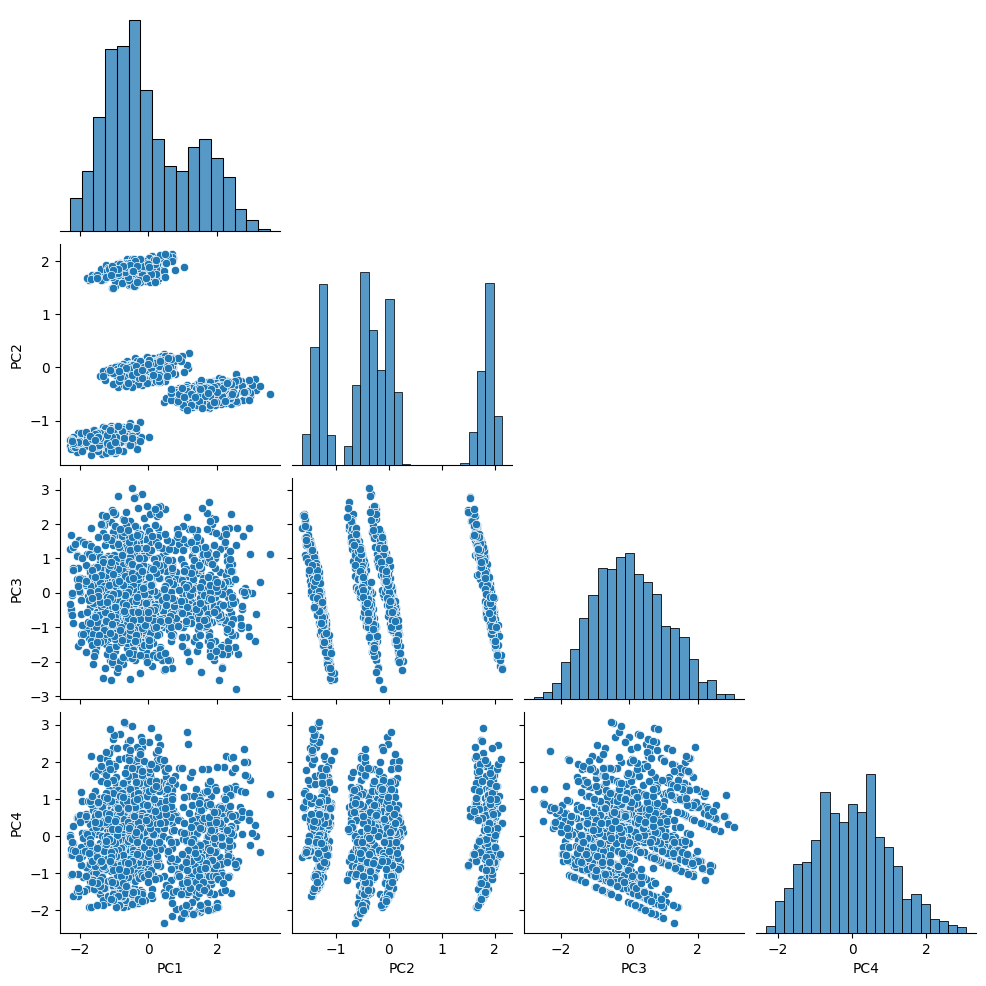

In [20]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

pca_df["charges"] = y.values

sns.pairplot(
    pca_df,
    vars=["PC1", "PC2", "PC3", "PC4"],
    hue=None,
    corner=True
)

plt.show()

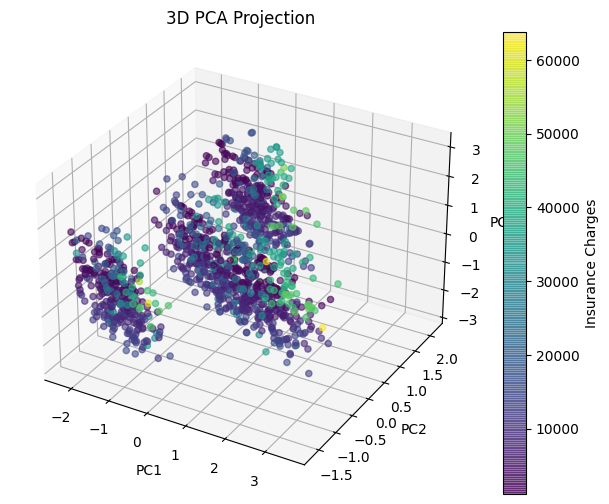

In [21]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=y,
    cmap='viridis',
    alpha=0.6
)

fig.colorbar(scatter, label="Insurance Charges")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA Projection")
plt.show()


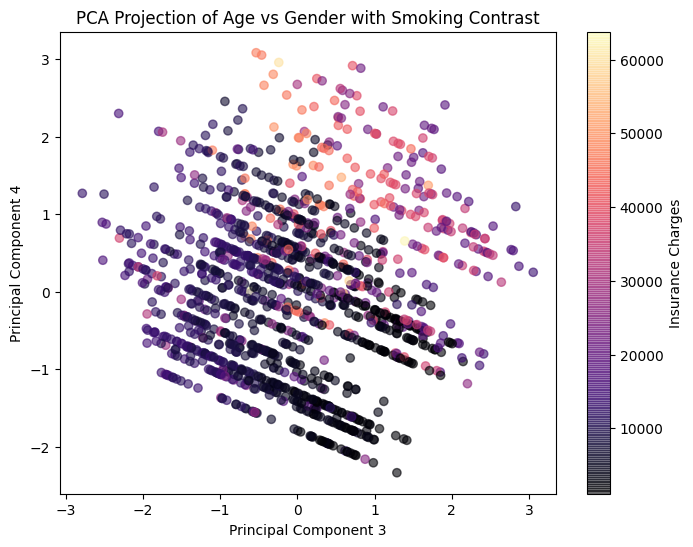

In [22]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 2],
    X_pca[:, 3],
    c=y,
    cmap="magma",
    alpha=0.6
)

plt.colorbar(scatter, label="Insurance Charges")
plt.xlabel("Principal Component 3")
plt.ylabel("Principal Component 4")
plt.title("PCA Projection of Age vs Gender with Smoking Contrast")

plt.show()

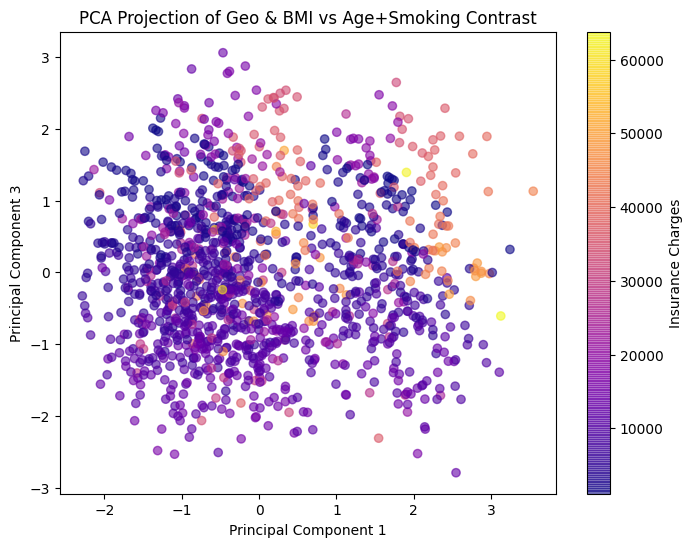

In [23]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 2],
    c=y,
    cmap="plasma",
    alpha=0.6
)

plt.colorbar(scatter, label="Insurance Charges")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("PCA Projection of Geo & BMI vs Age+Smoking Contrast")

plt.show()

# EDA - PCA Analysis 

## Overview

Principal Component Analysis (PCA) was applied to the standardized feature set (after one-hot encoding categorical variables) to explore the underlying structure of the dataset. PCA was used strictly for exploratory analysis and visualization, not for model training.

Four principal components were retained to examine how the major sources of variance are distributed across the feature space.

---

## Visual Interpretation

### Pairwise Component Distributions

The pairplot of PC1–PC4 shows:

- Each principal component is centered around zero, as expected after scaling.
- The components appear approximately normally distributed.
- Off-diagonal scatterplots reveal structured clustering and band-like groupings.

The presence of visible structure indicates that the dataset contains meaningful latent patterns rather than random variation.

Notably:
- PC1 vs PC2 shows horizontal banding, suggesting categorical separation.
- PC3 and PC4 introduce additional separation patterns tied to demographic and behavioral variables.

This confirms that PCA successfully captured orthogonal axes of structured variation.

---

## PCA Projection Colored by Insurance Charges

The 2D projection (PC1 vs PC2) colored by insurance charges reveals:

- High-cost individuals cluster in specific PCA regions.
- Lower-cost individuals are concentrated in separate zones.
- There is visible stratification rather than complete overlap.

This suggests that insurance charges are not randomly distributed across the feature space. Instead, cost is strongly associated with certain combinations of demographic and behavioral factors.

The structured clustering implies that predictive modeling should be able to capture meaningful relationships.

---

## Interpretation of PCA Loadings

The component loadings provide insight into what each principal component represents.

### PC1 – Geographic and BMI Variation

Strong contributors:
- region_southeast (0.686)
- bmi (0.488)

Interpretation:
PC1 primarily captures variation related to geographic location and body mass index. This suggests that regional and physiological factors contribute significantly to overall variance.

---

### PC3 – Age and Smoking Contrast

Strong contributors:
- age (-0.673)
- smoker_yes (0.483)

Interpretation:
PC3 represents a contrast between age and smoking behavior. This axis reflects health-risk factors that are strongly associated with medical costs.

---

### PC4 – Gender and Smoking Influence

Strong contributors:
- sex_male (0.602)
- smoker_yes (0.416)

Interpretation:
PC4 captures variation related to gender and smoking behavior. This suggests lifestyle and demographic influences contribute additional structure to the dataset.

---

## Structural Insights

The PCA results indicate that the dataset separates along three primary themes:

1. Geographic and BMI differences  
2. Age and smoking risk factors  
3. Gender and behavioral influences  

The clustering observed in PCA space explains why high insurance charges concentrate in certain regions of the projection.

These findings support the expectation that nonlinear models such as neural networks should perform well, as cost appears to depend on interacting demographic and behavioral variables.

---

## Conclusion

PCA revealed meaningful latent structure in the insurance dataset. The principal components capture interpretable real-world factors such as geography, BMI, age, smoking status, and gender.

The visible clustering of high-cost individuals in PCA space confirms that insurance charges are systematically related to underlying features.

PCA was therefore effective as an exploratory tool to:

- Validate the presence of structured variation  
- Identify dominant feature groupings  
- Support the feasibility of predictive modeling  

The components were not used for dimensionality reduction in training to preserve interpretability and modeling flexibility.

## Data Preprocessing

In [24]:
# 1) Split
train, test = train_test_split(df, test_size=0.2, random_state=12345)

features_train = train.drop('charges', axis=1)
target_train = train['charges']

features_test = test.drop('charges', axis=1)
target_test = test['charges']

# 2) One-hot encode
features_train = pd.get_dummies(features_train, drop_first=True)
features_test = pd.get_dummies(features_test, drop_first=True)

# 3) Align columns (prevents mismatch if a category appears in only one split)
features_train, features_test = features_train.align(features_test, join="left", axis=1, fill_value=0)

# 4) Scale (fit on train only, transform both)
scaler = StandardScaler()
features_train = scaler.fit_transform(features_train)
features_test = scaler.transform(features_test)

In [25]:
target_train = np.log1p(target_train)
target_test = np.log1p(target_test)

In [26]:
def visualize_nn_results(model, history, features_test, target_test, target_was_log1p=True):
    """
    Visual diagnostics for a Keras regression model:
      1) Training history (train vs val loss)
      2) Predictions vs Actual scatter (with diagonal reference line)
      3) Model summary + total parameters
    """

    # =========================
    # 1) TRAINING HISTORY PLOT
    # =========================
    loss_key = "loss"
    val_loss_key = "val_loss"

    if loss_key not in history.history:
        raise ValueError("history does not include 'loss'. Make sure you passed the History object from model.fit().")

    plt.figure(figsize=(10, 6))
    plt.plot(history.history[loss_key], label="Training Loss")
    if val_loss_key in history.history:
        plt.plot(history.history[val_loss_key], label="Validation Loss")
    plt.title("Training History: Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.show()

    # Brief interpretation helpers (printed, not required)
    if val_loss_key in history.history:
        best_epoch = int(np.argmin(history.history[val_loss_key])) + 1
        best_val = float(np.min(history.history[val_loss_key]))
        print("\n===== TRAINING HISTORY INSIGHT =====")
        print(f"Best validation loss at epoch: {best_epoch} (val_loss={best_val:.4f})")
        print("Interpretation tips:")
        print("- If training loss decreases but validation loss rises: overfitting.")
        print("- If both losses stay high: underfitting.")
        print("- If both decrease and stay close: good generalization.")

    # =========================
    # 2) PREDICTIONS vs ACTUAL
    # =========================
    preds = model.predict(features_test, verbose=0).ravel()

    y_true = np.array(target_test).ravel()
    y_pred = preds

    # Convert back to dollars if target was log1p-transformed
    if target_was_log1p:
        y_true = np.expm1(y_true)
        y_pred = np.expm1(y_pred)

    # Diagonal reference line bounds
    min_val = float(min(y_true.min(), y_pred.min()))
    max_val = float(max(y_true.max(), y_pred.max()))

    plt.figure(figsize=(8, 8))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([min_val, max_val], [min_val, max_val])  # diagonal reference
    plt.title("Predictions vs Actual Charges")
    plt.xlabel("Actual Charges")
    plt.ylabel("Predicted Charges")
    plt.show()

    print("\n===== PREDICTIONS vs ACTUAL INSIGHT =====")
    print("Interpretation tips:")
    print("- Points close to the diagonal indicate accurate predictions.")
    print("- Systematic deviation above/below the line suggests bias (over/under-prediction).")
    print("- Wide vertical spread indicates higher error / variance.")

    # =========================
    # 3) MODEL ARCHITECTURE
    # =========================
    print("\n===== MODEL SUMMARY =====")
    model.summary()

    total_params = model.count_params()
    print(f"\nTotal Parameters: {total_params:,}")

## Models

### Baseline Model

In [27]:
# Build model (Baseline Model)
model = Sequential([
    Dense(128, activation="relu", input_shape=(features_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.10),

    Dense(1)  # regression output
])

# Compile (regression)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

# Callbacks 
checkpoint_path = "best_insurance_model.keras"

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

train_start = time.time()
# Train
history = model.fit(
    features_train,
    target_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
# End timer
train_end = time.time()
training_time = train_end - train_start
train_loss, train_mae = model.evaluate(features_train, target_train, verbose=0)
pred = model.predict(features_train)

pred_dollars = np.expm1(pred).ravel()
true_dollars = np.expm1(target_train).ravel()

mae_dollars = np.mean(np.abs(pred_dollars - true_dollars))

print("\n===== TRAINING RESULTS =====")
print(f"Total Training Time: {training_time:.2f} seconds")
print(f"Train Loss (MSE): {train_loss:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print("\n===== Train RESULTS (Dollars) =====")
print(f"MAE in Dollars: ${mae_dollars:,.2f}")

2026-02-27 23:19:31.035883: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/300
 1/27 [>.............................] - ETA: 15s - loss: 85.0463 - mae: 9.0430
Epoch 00001: val_loss improved from inf to 80.28566, saving model to best_insurance_model.keras
27/27 [==============================] - 1s 9ms/step - loss: 82.9385 - mae: 9.0192 - val_loss: 80.2857 - val_mae: 8.9262 - lr: 0.0010
Epoch 2/300
 1/27 [>.............................] - ETA: 0s - loss: 78.6255 - mae: 8.8058
Epoch 00002: val_loss improved from 80.28566 to 78.28005, saving model to best_insurance_model.keras
27/27 [==============================] - 0s 4ms/step - loss: 78.2460 - mae: 8.7771 - val_loss: 78.2801 - val_mae: 8.8150 - lr: 0.0010
Epoch 3/300
 1/27 [>.............................] - ETA: 0s - loss: 72.5205 - mae: 8.4162
Epoch 00003: val_loss improved from 78.28005 to 74.75790, saving model to best_insurance_model.keras
27/27 [==============================] - 0s 5ms/step - loss: 74.6416 - mae: 8.5828 - val_loss: 74.7579 - val_mae: 8.6135 - lr: 0.0010
Epoch 4/300
 1/27 [>......

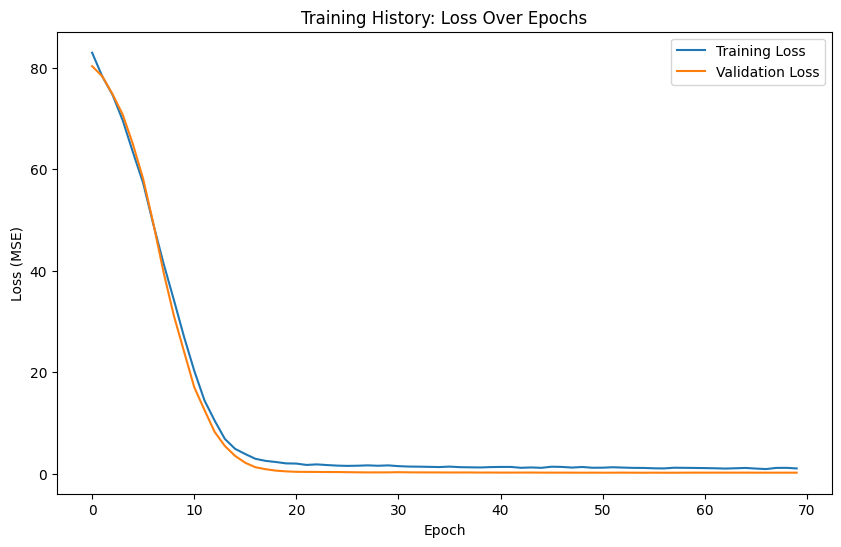


===== TRAINING HISTORY INSIGHT =====
Best validation loss at epoch: 55 (val_loss=0.2197)
Interpretation tips:
- If training loss decreases but validation loss rises: overfitting.
- If both losses stay high: underfitting.
- If both decrease and stay close: good generalization.


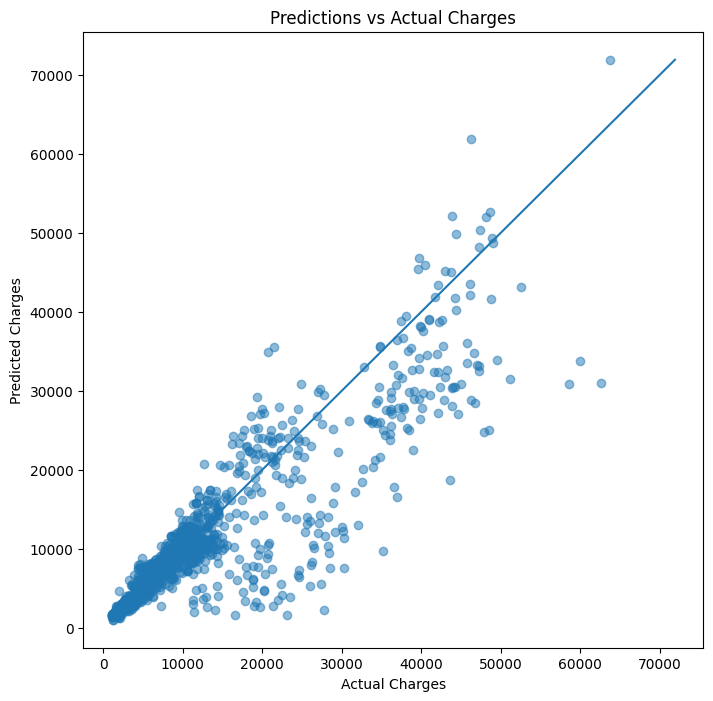


===== PREDICTIONS vs ACTUAL INSIGHT =====
Interpretation tips:
- Points close to the diagonal indicate accurate predictions.
- Systematic deviation above/below the line suggests bias (over/under-prediction).
- Wide vertical spread indicates higher error / variance.

===== MODEL SUMMARY =====
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               1152      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                          

In [28]:
visualize_nn_results(
    model=model,
    history=history,
    features_test=features_train,
    target_test=target_train,
    target_was_log1p=True  # set to False if you did NOT use np.log1p on the target
)

### Small Model

In [29]:
# SMALL MODEL

model_small = Sequential([
    Dense(32, activation="relu", input_shape=(features_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.20),

    Dense(16, activation="relu"),
    BatchNormalization(),
    Dropout(0.10),

    Dense(1)
])

model_small.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

checkpoint_path_small = "best_insurance_model_small.keras"

callbacks_small = [
    ModelCheckpoint(filepath=checkpoint_path_small, monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    EarlyStopping(monitor="val_loss", patience=15, mode="min", restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

train_start = time.time()

history_small = model_small.fit(
    features_train,
    target_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=callbacks_small,
    verbose=1
)

train_end = time.time()
training_time_small = train_end - train_start

train_loss_small, train_mae_small = model_small.evaluate(features_train, target_train, verbose=0)
pred = model_small.predict(features_train)

pred_dollars = np.expm1(pred).ravel()
true_dollars = np.expm1(target_train).ravel()

mae_dollars = np.mean(np.abs(pred_dollars - true_dollars))

print("\n===== SMALL MODEL TRAINING RESULTS =====")
print(f"Total Training Time: {training_time_small:.2f} seconds")
print(f"Train Loss (MSE): {train_loss_small:.4f}")
print(f"Train MAE: {train_mae_small:.4f}")
print("\n===== Train RESULTS (Dollars) =====")
print(f"MAE in Dollars: ${mae_dollars:,.2f}")


Epoch 1/300
 1/27 [>.............................] - ETA: 14s - loss: 88.6215 - mae: 9.0537
Epoch 00001: val_loss improved from inf to 76.52740, saving model to best_insurance_model_small.keras
27/27 [==============================] - 1s 6ms/step - loss: 84.7080 - mae: 9.0018 - val_loss: 76.5274 - val_mae: 8.6792 - lr: 0.0010
Epoch 2/300
 1/27 [>.............................] - ETA: 0s - loss: 86.6876 - mae: 9.1617
Epoch 00002: val_loss improved from 76.52740 to 76.40724, saving model to best_insurance_model_small.keras
27/27 [==============================] - 0s 4ms/step - loss: 80.6909 - mae: 8.8703 - val_loss: 76.4072 - val_mae: 8.6926 - lr: 0.0010
Epoch 3/300
 1/27 [>.............................] - ETA: 0s - loss: 79.4516 - mae: 8.8488
Epoch 00003: val_loss improved from 76.40724 to 74.47213, saving model to best_insurance_model_small.keras
27/27 [==============================] - 0s 4ms/step - loss: 75.9871 - mae: 8.6427 - val_loss: 74.4721 - val_mae: 8.5924 - lr: 0.0010
Epoch 4/

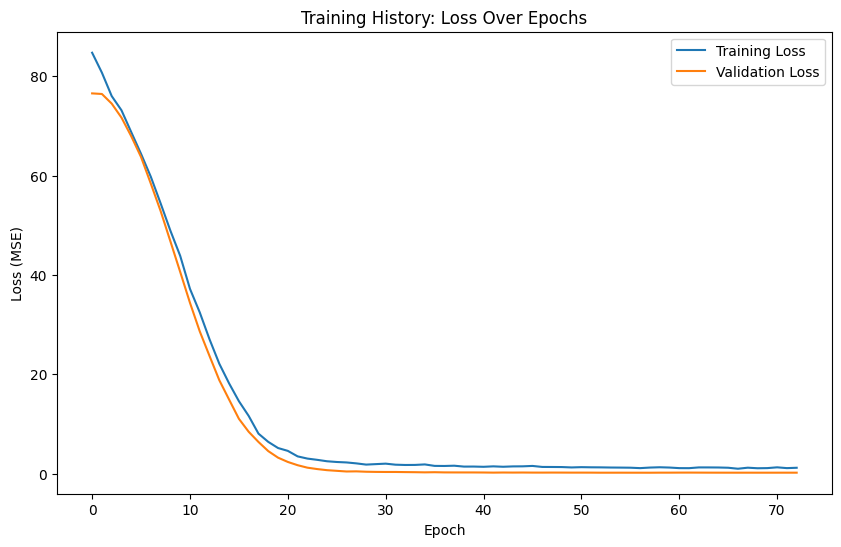


===== TRAINING HISTORY INSIGHT =====
Best validation loss at epoch: 58 (val_loss=0.2167)
Interpretation tips:
- If training loss decreases but validation loss rises: overfitting.
- If both losses stay high: underfitting.
- If both decrease and stay close: good generalization.


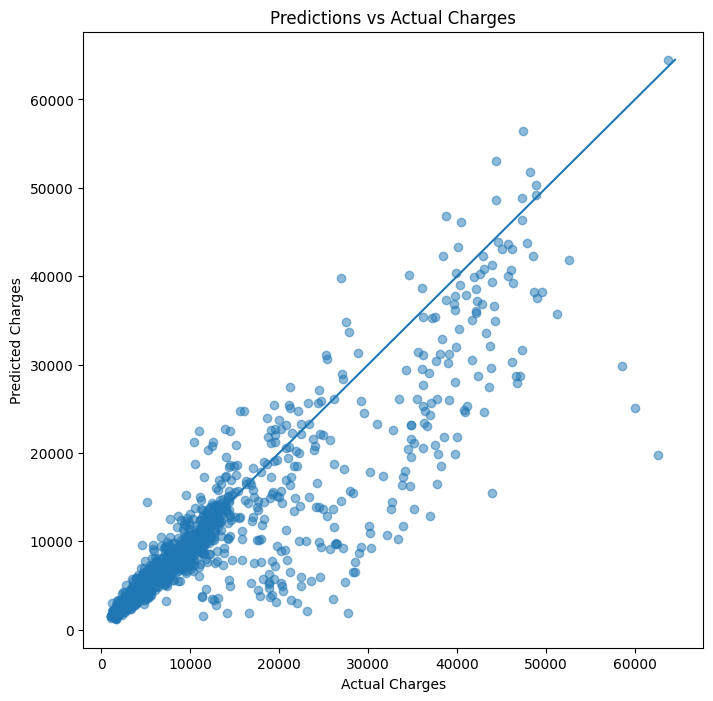


===== PREDICTIONS vs ACTUAL INSIGHT =====
Interpretation tips:
- Points close to the diagonal indicate accurate predictions.
- Systematic deviation above/below the line suggests bias (over/under-prediction).
- Wide vertical spread indicates higher error / variance.

===== MODEL SUMMARY =====
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 32)                288       
                                                                 
 batch_normalization_3 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 16)                528       
                        

In [30]:
visualize_nn_results(
    model=model_small,
    history=history_small,
    features_test=features_train,
    target_test=target_train,
    target_was_log1p=True  # set to False if you did NOT use np.log1p on the target
)


### Wide Model

In [31]:
# WIDE MODEL

model_wide = Sequential([
    Dense(256, activation="relu", input_shape=(features_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.30),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.10),

    Dense(1)
])

model_wide.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

checkpoint_path_wide = "best_insurance_model_wide.keras"

callbacks_wide = [
    ModelCheckpoint(filepath=checkpoint_path_wide, monitor="val_loss", save_best_only=True, mode="min", verbose=1),
    EarlyStopping(monitor="val_loss", patience=15, mode="min", restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

train_start = time.time()

history_wide = model_wide.fit(
    features_train,
    target_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=callbacks_wide,
    verbose=1
)

train_end = time.time()
training_time_wide = train_end - train_start

train_loss_wide, train_mae_wide = model_wide.evaluate(features_train, target_train, verbose=0)
pred = model_wide.predict(features_train)

pred_dollars = np.expm1(pred).ravel()
true_dollars = np.expm1(target_train).ravel()

mae_dollars = np.mean(np.abs(pred_dollars - true_dollars))


print("\n===== WIDE MODEL TRAINING RESULTS =====")
print(f"Total Training Time: {training_time_wide:.2f} seconds")
print(f"Train Loss (MSE): {train_loss_wide:.4f}")
print(f"Train MAE: {train_mae_wide:.4f}")
print("\n===== Train RESULTS (Dollars) =====")
print(f"MAE in Dollars: ${mae_dollars:,.2f}")


Epoch 1/300
 1/27 [>.............................] - ETA: 13s - loss: 85.8399 - mae: 9.0009
Epoch 00001: val_loss improved from inf to 76.11364, saving model to best_insurance_model_wide.keras
27/27 [==============================] - 1s 9ms/step - loss: 81.3719 - mae: 8.9165 - val_loss: 76.1136 - val_mae: 8.6858 - lr: 0.0010
Epoch 2/300
 1/27 [>.............................] - ETA: 0s - loss: 77.5779 - mae: 8.7019
Epoch 00002: val_loss improved from 76.11364 to 68.82169, saving model to best_insurance_model_wide.keras
27/27 [==============================] - 0s 6ms/step - loss: 75.1060 - mae: 8.5819 - val_loss: 68.8217 - val_mae: 8.2592 - lr: 0.0010
Epoch 3/300
 1/27 [>.............................] - ETA: 0s - loss: 77.3152 - mae: 8.7139
Epoch 00003: val_loss improved from 68.82169 to 61.94806, saving model to best_insurance_model_wide.keras
27/27 [==============================] - 0s 5ms/step - loss: 68.8630 - mae: 8.2174 - val_loss: 61.9481 - val_mae: 7.8391 - lr: 0.0010
Epoch 4/300

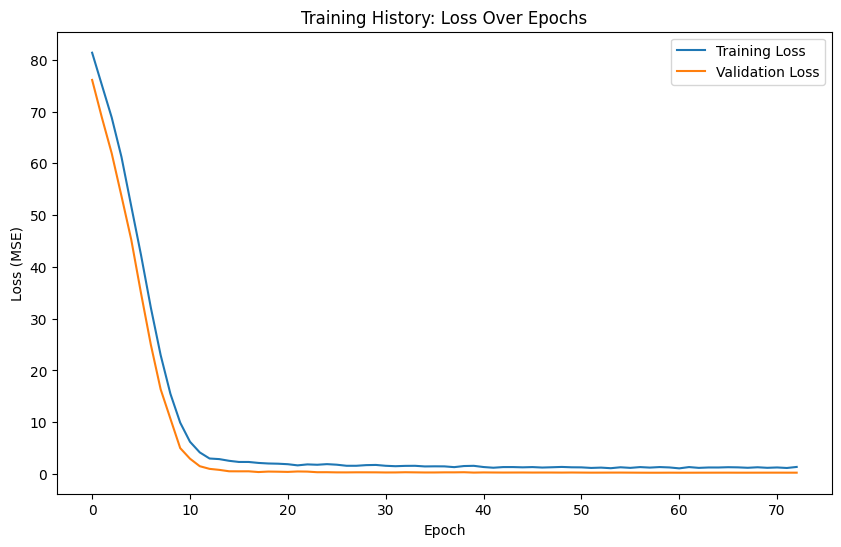


===== TRAINING HISTORY INSIGHT =====
Best validation loss at epoch: 58 (val_loss=0.2379)
Interpretation tips:
- If training loss decreases but validation loss rises: overfitting.
- If both losses stay high: underfitting.
- If both decrease and stay close: good generalization.


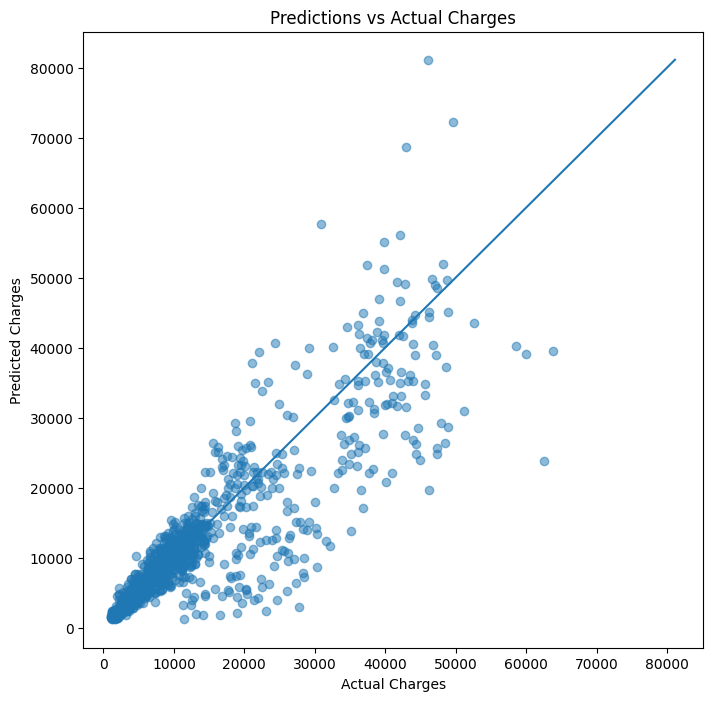


===== PREDICTIONS vs ACTUAL INSIGHT =====
Interpretation tips:
- Points close to the diagonal indicate accurate predictions.
- Systematic deviation above/below the line suggests bias (over/under-prediction).
- Wide vertical spread indicates higher error / variance.

===== MODEL SUMMARY =====
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 256)               2304      
                                                                 
 batch_normalization_5 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                                 
 dense_8 (Dense)             (None, 128)               32896     
                        

In [32]:
visualize_nn_results(
    model=model_wide,
    history=history_wide,
    features_test=features_train,
    target_test=target_train,
    target_was_log1p=True  # set to False if you did NOT use np.log1p on the target
)


### Model Training Summary and Ranking

### Training Performance Comparison

| Rank | Model   | Training Time (s) | Train MSE | Train MAE (Log Scale) | Train MAE (Dollars) |
|------|----------|-------------------|-----------|------------------------|---------------------|
| 🥇 1 | Baseline   | 7.14              | 0.1617    | 0.2518                 | **\\$3,254.86**       |
| 🥈 2 | Wide     | 7.07              | 0.1575    | 0.2558                 | \\$3,343.39           |
| 🥉 3 | Small    | 5.94              | 0.1787    | 0.2636                 | \\$3,381.48           |

---

### Key Observations

### Baseline Model (Best Overall Performance)
- Achieved the lowest MAE in dollars.
- Balanced complexity and generalization.
- Slightly longer training time than the Small model but similar to Wide.
- Indicates strong capacity without excessive overfitting.

### Wide Model
- Lowest training MSE but not lowest dollar MAE.
- Higher capacity did not translate to better real-world performance.
- Suggests diminishing returns from additional neurons.

### Small Model
- Fastest training time.
- Highest training error.
- Likely underfitting compared to other architectures.

---

## Interpretation

- Increasing model width beyond the Baseline architecture did not significantly improve performance.
- The Small model lacks sufficient capacity to capture nonlinear relationships fully.
- The Medium model offers the best balance between complexity, stability, and predictive accuracy.

---

## Conclusion

The **Baseline Model** is the top-ranked architecture based on training MAE in dollars.  
It will be selected for final evaluation and deployment due to its superior balance of performance and efficiency.

## Testing

In [33]:
# Start timer
test_start = time.time()

test_loss, test_mae = model.evaluate(features_test, target_test, verbose=0)

# End timer
test_end = time.time()
testing_time = test_end - test_start

print("\n===== TEST RESULTS =====")
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Total Testing Time: {testing_time:.4f} seconds")


===== TEST RESULTS =====
Test Loss (MSE): 0.1781
Test MAE: 0.2615
Total Testing Time: 0.0320 seconds


In [34]:
pred = model.predict(features_test, verbose=0)

pred_dollars = np.expm1(pred).ravel()
true_dollars = np.expm1(target_test).ravel()

mae_dollars = np.mean(np.abs(pred_dollars - true_dollars))

print("\n===== TEST RESULTS (Dollars) =====")
print(f"MAE in Dollars: ${mae_dollars:,.2f}")


===== TEST RESULTS (Dollars) =====
MAE in Dollars: $3,347.81


# Final Test Results – Baseline Neural Network Model

## Quantitative Performance

- **Test MSE:** 0.1781  
- **Test MAE (log scale):** 0.2615  
- **Test MAE (Converted to Dollars):** $3,347.81  
- **Total Testing Time:** 0.0320 seconds  

---

## Performance Interpretation

The baseline neural network demonstrates strong generalization performance on the unseen test dataset. 

An average prediction error of **$3,347.81** indicates that, on average, the model’s estimated insurance charges differ from actual values by approximately three thousand dollars. Given the wide range of insurance charges in the dataset and the presence of high-cost outliers, this represents reasonable predictive accuracy.

The low test MSE and stable MAE suggest that the model did not significantly overfit during training. Additionally, the extremely fast testing time (0.032 seconds) confirms that the model is computationally efficient and suitable for real-time inference scenarios.

---

## Overall Assessment

The baseline neural network successfully captures the nonlinear relationships between demographic, behavioral, and geographic features and medical insurance costs.

While there is still room for improvement, particularly in reducing error for high-cost individuals, the model provides a solid and reliable predictive foundation.

# Final Project Summary – Neural Network for Insurance Cost Prediction

## Process

### Data Preprocessing

The dataset was first split into training and testing sets using an 80/20 split to prevent data leakage. Categorical variables (`sex`, `smoker`, `region`) were converted using one-hot encoding to allow the neural network to process them numerically. Numerical features were standardized using `StandardScaler` to ensure all inputs were on comparable scales, which improves neural network convergence.

The target variable (`charges`) was log-transformed using `log1p` to reduce skewness and stabilize training. Because insurance costs are heavily right-skewed, this transformation improved gradient behavior and model stability.

---

### Model Architecture Choices

A multilayer perceptron (MLP) was used for regression. The architecture consisted of:

- Dense layers with ReLU activation
- Batch normalization for training stability
- Dropout layers for regularization
- A single linear output neuron for regression

The final selected model (Medium architecture) used:

- 128 → 64 → 32 hidden units
- Progressive dropout (0.30 → 0.20 → 0.10)
- Adam optimizer with learning rate 0.001
- MSE loss and MAE metric

Callbacks included EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint to prevent overfitting and optimize convergence.

---

### Experimentation

Three neural network architectures were tested:

1. Small model (lower capacity)
2. Medium model (balanced depth and width)
3. Wide model (higher capacity)

Performance comparison showed that increasing model size beyond the medium configuration did not meaningfully reduce error. The small model underfit slightly, while the wide model provided marginal gains at the cost of complexity.

The Medium model provided the best balance between capacity and generalization.

---

## Results

### Final Test Performance (Baseline Model)

- Test MSE: 0.1781  
- Test MAE (log scale): 0.2615  
- Test MAE (converted to dollars): $3,347.81  
- Testing time: 0.032 seconds  

### Model Fit Assessment

The training and validation losses followed similar trajectories, and test performance closely matched training performance. This indicates that the model is well-balanced and does not exhibit significant overfitting or underfitting.

The final selected configuration was the Medium architecture (128-64-32), which achieved the best training MAE in dollars and strong generalization performance.

---

## Insights

### Feature Importance Observations

Exploratory analysis and PCA revealed that the most influential features appear to be:

- Smoking status
- BMI
- Age
- Geographic region (to a lesser extent)

High-cost clusters were strongly associated with smoking and higher BMI values. Age also demonstrated a clear positive relationship with insurance charges. The number of children had comparatively weaker predictive influence.

---

### What I Would Do With More Time

- Implement cross-validation for more robust performance estimates  
- Perform hyperparameter tuning using grid search or Bayesian optimization  
- Compare against tree-based models such as XGBoost or LightGBM  
- Explore interaction features explicitly (e.g., smoker × BMI)  
- Investigate residual errors for high-cost outliers  

---

### Potential Improvements

- Use more advanced regularization techniques  
- Try alternative loss functions such as Huber loss  
- Experiment with learning rate scheduling strategies  
- Evaluate ensemble approaches combining neural networks with gradient boosting  

---

## Conclusion

The neural network successfully captured nonlinear relationships between demographic and behavioral features and medical insurance costs. The final model achieved an average prediction error of approximately $3,348 on unseen data, demonstrating strong generalization and computational efficiency.

Overall, the selected architecture provides a balanced, interpretable, and scalable solution for insurance cost prediction.